# Phase 1: 数据集整理 (DataSet exposing)

## 概述 Overview

本Notebook文件基于Phase1脚本修改而来，目标为按照一定比例，融合不同专利的数据集，形成测试集和验证集，并且将测试集合和验证集合命名为feature-engineering_{train/test}.csv和npz文件
筛选操作也是同样做处理

另外，为了配合更多分子表征的操作，这里新增了ChemBerta分子表征的内容，ChemBerta分子表征默认数值为384，这个暂时还不知道怎么处理

**主要步骤：**
* 4268数据集合完全划分到训练集中
* 剩下的所有数据7为训练集，3为测试集合
* 经过数据集划分验证，得知当前的划分方式基本合理
* 新增了ChemBerta分子表征内容

**生成结果**
* csv文件（没有processed后缀，存放在data/feature-engineering/csv文件夹下方）
* npz文件（没有processed后缀，存放在data/feature-engineering/feature下方）

**输入**: `data/raw/*.csv` - 原始数据文件  
**输出**: 
- `data/feature-engineering/csv/*.csv` - 添加分子特征后的CSV  
- `data/feature-engineering/feature/*.npz` - RDKit特征矩阵   


---

## 1. 环境检查与导入 Environment Setup

In [65]:
# 环境检查
import sys
from pathlib import Path

# 添加项目根目录到路径
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

# 核心库导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# 项目模块导入
from feature_extraction import PeptideFeaturizer
from feature_extraction.utils import (
    get_csv_files, load_csv_safely, extract_molecular_features,
    convert_label_to_minutes, save_features_to_npz
)

# 设置显示选项
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("✓ 所有库已成功导入")
print(f"✓ 项目根目录: {project_root}")




✓ 所有库已成功导入
✓ 项目根目录: d:\RA\feature_extraction


## 2. 参数配置区 Configuration

**⚙️ 根据您的需求修改以下参数**

In [66]:
# ============== 参数配置区 ==============
# 用户可根据需要修改以下参数

CONFIG = {
    # 读入数据路径
    'raw_dir': project_root / 'data' / 'raw',
    # csv输出路径
    'processed_dir': project_root / 'data' / 'feature-engineering' / 'csv',
    'features_dir': project_root / 'data' / 'feature-engineering' / 'features',
    'figures_dir': project_root / 'data' / 'feature-engineering'/ 'figures' / 'phase1',

    # 备注信息：（用于挑选对应的数据和特征）
    'message':"Morgan(1024)_Avalon(512)_ChemBERTa(384)",
    
    # 特征提取参数
    'morgan_bits': 1024, #1024,     # Morgan指纹位数（这里临时修改为0，关闭特征提取）
    'avalon_bits': 512,      # Avalon指纹位数512
    'chemberta_bits': 384,   # 根据目前所知，这个只有0和384，剩下改了都没用
    # （放在外面配置了）'use_avalon': True ,      # 是否使用Avalon指纹（需RDKit支持） 

    # 可视化参数
    'dpi': 300,              # 图像分辨率
    'format': 'png',         # 图像格式 (png/pdf/svg)
    'display_plots': True,   # 是否在notebook中显示关键图表
    'max_display_plots': 3,  # 最多显示几个图表
    'split_random':42
}

# 追加配置
CONFIG['use_avalon'] = True if CONFIG['avalon_bits'] > 0 else False  # 是否使用Avalon指纹（需RDKit支持）
CONFIG['use_chemberta'] = True if CONFIG['chemberta_bits'] > 0 else False  # 是否使用Avalon指纹（需RDKit支持）

# 创建输出目录
CONFIG['processed_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['features_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['figures_dir'].mkdir(parents=True, exist_ok=True)

print("配置参数:")
for key, value in CONFIG.items():
    if isinstance(value, Path):
        print(f"  {key}: {value.relative_to(project_root) if value.is_relative_to(project_root) else value}")
    else:
        print(f"  {key}: {value}")

配置参数:
  raw_dir: data\raw
  processed_dir: data\feature-engineering\csv
  features_dir: data\feature-engineering\features
  figures_dir: data\feature-engineering\figures\phase1
  message: Morgan(1024)_Avalon(512)_ChemBERTa(384)
  morgan_bits: 1024
  avalon_bits: 512
  chemberta_bits: 384
  dpi: 300
  format: png
  display_plots: True
  max_display_plots: 3
  split_random: 42
  use_avalon: True
  use_chemberta: True


## 3. 步骤 1: 添加分子特征 Add Molecular Features

为每个SMILES分子添加结构特征并转换标签格式。

**新增列**:
- `is_dimer`: 是否为二聚体 (bool)
- `is_cyclic`: 是否含环状结构 (bool)
- `has_disulfide_bond`: 是否含二硫键 (bool)
- `SIF_minutes`: SIF半衰期（分钟）
- `SGF_minutes`: SGF半衰期（分钟）

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

def process_and_merge_datasets(file_paths, full_train_names, train_ratio=0.7, message:str=""):
    """
    file_paths: list, 所有数据集的文件路径列表 (例如 ['data1.csv', 'patents.csv', ...])
    full_train_names: list, 需要全部作为训练集的文件名关键词 (例如 ['patents'])
    train_ratio: float, 其他数据集的训练集比例
    """
    train_list = []
    test_list = []

    for path in file_paths:
        # 1. 获取文件名并读取原始数据
        file_name = path
        csv_path = CONFIG['raw_dir'] / path
        print(f"正在处理: {file_name}")
        df = pd.read_csv(csv_path)
        
        # ------------------ 原有预处理逻辑开始 ------------------
        # 提取分子特征
        feature_records = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"处理 {file_name}", leave=False):
            smiles = row["SMILES"]
            features = extract_molecular_features(smiles)
            feature_records.append(features)
        
        # 添加特征列
        feature_df = pd.DataFrame(feature_records)
        df = pd.concat([df, feature_df], axis=1)
        
        # 转换标签到分钟
        sif_col = "SIF_class" if "SIF_class" in df.columns else None
        sgf_col = "SGF_class" if "SGF_class" in df.columns else None
        
        if sif_col:
            df["SIF_minutes"] = df[sif_col].apply(convert_label_to_minutes)
        else:
            df["SIF_minutes"] = -1
        
        if sgf_col:
            df["SGF_minutes"] = df[sgf_col].apply(convert_label_to_minutes)
        else:
            df["SGF_minutes"] = -1
        
        # 过滤双标签缺失的样本
        mask_both_missing = (df["SIF_minutes"] == -1) & (df["SGF_minutes"] == -1)
        df_processed = df[~mask_both_missing].copy()
        # ------------------ 原有预处理逻辑结束 ------------------

        # 2. 划分与合并逻辑
        # 判断当前处理好的 df_processed 应该往哪儿走
        is_full_train = any(name in file_name for name in full_train_names)
        
        if is_full_train:
            print(f"--- 模式: {file_name} 全量加入训练集")
            train_list.append(df_processed)
        else:
            # 按照 7:3 划分处理后的数据
            if len(df_processed) < 2:
                print(f"--- 警告: {file_name} 数据量过小，全量计入训练集")
                train_list.append(df_processed)
            else:
                print(f"--- 模式: {file_name} 按 7:3 划分")
                train_df, test_df = train_test_split(
                    df_processed, 
                    train_size=train_ratio, 
                    random_state= CONFIG['split_random'],    # 这里修改划分的随机种子
                    shuffle=True
                )
                train_list.append(train_df)
                test_list.append(test_df)
        
    # 合并所有数据
    final_train = pd.concat(train_list, ignore_index=True)
    final_test = pd.concat(test_list, ignore_index=True) if test_list else pd.DataFrame()

    # 输出结果
    final_train.to_csv(CONFIG["processed_dir"]/f'feature-engineering_train_{message}.csv', index=False)
    final_test.to_csv(CONFIG["processed_dir"]/f'feature-engineering_test_{message}.csv', index=False)

    print("\n" + "="*30)
    print(f"合并完成！")
    print(f"最终训练集样本数: {len(final_train)}")
    print(f"最终测试集样本数: {len(final_test)}")
    print("="*30)

# --- 使用示例 ---


# 执行：批量处理所有CSV文件
csv_files = list(CONFIG['raw_dir'].glob('*.csv'))
csv_files_names = [file.name for file in csv_files]
print(f"找到 {len(csv_files)} 个CSV文件\n")

# 指定特定数据集加入训练集合
special_datasets = ['US9624268.csv'] 
process_and_merge_datasets(csv_files_names, special_datasets,message=CONFIG['message'])
# 保留样本数目为932就对了


找到 5 个CSV文件

正在处理: sif_sgf_second.csv


处理 sif_sgf_second.csv:   0%|          | 0/897 [00:00<?, ?it/s]

--- 模式: sif_sgf_second.csv 按 7:3 划分
正在处理: US20140294902A1.csv


处理 US20140294902A1.csv:   0%|          | 0/5 [00:00<?, ?it/s]

--- 模式: US20140294902A1.csv 按 7:3 划分
正在处理: US9624268.csv


...

--- 模式: US9624268.csv 全量加入训练集
正在处理: US9809623B2.csv


处理 US9809623B2.csv:   0%|          | 0/80 [00:00<?, ?it/s]

--- 模式: US9809623B2.csv 按 7:3 划分
正在处理: WO2017011820A2.csv


处理 WO2017011820A2.csv:   0%|          | 0/174 [00:00<?, ?it/s]

--- 模式: WO2017011820A2.csv 按 7:3 划分

合并完成！
最终训练集样本数: 690
最终测试集样本数: 242


In [68]:
# 生成合并的csv文件

import pandas as pd
import os
from datetime import datetime

def merge_and_sample_csv(file1, file2, output_file, sample_frac=0.3, 
                         random_state=42, merge_how='vertical', on_key=None):
    """
    合并两个CSV文件并抽样生成新文件
    
    参数:
        file1, file2: 输入的CSV文件路径
        output_file: 输出文件路径
        sample_frac: 抽样比例，默认0.3(30%)
        random_state: 随机种子，确保结果可重现
        merge_how: 合并方式，'vertical'(纵向)或'horizontal'(横向)
        on_key: 横向合并时指定的键列
    """
    try:
        # 读取CSV文件
        print(f"正在读取文件: {file1}")
        df1 = pd.read_csv(file1)
        print(f"文件1形状: {df1.shape}")
        
        print(f"正在读取文件: {file2}")
        df2 = pd.read_csv(file2)
        print(f"文件2形状: {df2.shape}")
        
        # 根据指定方式合并数据
        if merge_how == 'vertical':
            # 纵向拼接（沿行方向）[1,4](@ref)
            merged_df = pd.concat([df1, df2], axis=0, ignore_index=True)
            print(f"纵向合并后数据形状: {merged_df.shape}")
            
        elif merge_how == 'horizontal':
            # 横向拼接（沿列方向）[1,4](@ref)
            if on_key is None:
                # 直接按索引合并
                merged_df = pd.concat([df1, df2], axis=1)
            else:
                # 按键列合并，类似SQL JOIN操作[3,6](@ref)
                merged_df = pd.merge(df1, df2, on=on_key, how='inner')
            print(f"横向合并后数据形状: {merged_df.shape}")
        else:
            raise ValueError("merge_how参数必须是'vertical'或'horizontal'")
        
        # 检查数据量是否足够抽样
        if len(merged_df) == 0:
            print("警告: 合并后数据为空！")
            return False
            
        if len(merged_df) < 10:
            print("警告: 数据量较少，抽样结果可能不具有代表性")
        
        # 随机抽样30%的数据[7,8,9](@ref)
        sampled_df = merged_df.sample(frac=sample_frac, random_state=random_state)
        print(f"抽样后数据形状: {sampled_df.shape} (比例: {sample_frac*100}%)")
        
        # 保存结果到新文件[2,3](@ref)
        sampled_df.to_csv(output_file, index=False)
        print(f"✓ 结果已保存到: {output_file}")
        
        # 生成简单的处理报告
        generate_report(merged_df, sampled_df, output_file)
        
        return True
        
    except FileNotFoundError as e:
        print(f"错误: 文件不存在 - {e}")
        return False
    except Exception as e:
        print(f"错误: 处理过程中出现异常 - {e}")
        return False

def generate_report(merged_df, sampled_df, output_file):
    """生成处理报告"""
    print("\n" + "="*50)
    print("处理报告")
    print("="*50)
    print(f"合并后总数据量: {len(merged_df):,} 行")
    print(f"抽样后数据量: {len(sampled_df):,} 行")
    print(f"抽样比例: {len(sampled_df)/len(merged_df)*100:.1f}%")
    print(f"输出文件: {output_file}")
    print(f"处理时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    # 基本统计信息
    if len(merged_df.columns) <= 10:  # 避免列太多时输出过于冗长
        print(f"数据列: {', '.join(merged_df.columns.tolist())}")

# 基本使用：纵向合并两个文件并抽样30%
'''
merge_and_sample_csv(CONFIG["processed_dir"]/f"feature-engineering_train_{CONFIG['message']}.csv"
                     , CONFIG["processed_dir"]/f"feature-engineering_test_{CONFIG['message']}.csv", 
                     CONFIG["processed_dir"]/f"feature-engineering_mixture_{CONFIG['message']}.csv")
'''

'\nmerge_and_sample_csv(CONFIG["processed_dir"]/f"feature-engineering_train_{CONFIG[\'message\']}.csv"\n                     , CONFIG["processed_dir"]/f"feature-engineering_test_{CONFIG[\'message\']}.csv", \n                     CONFIG["processed_dir"]/f"feature-engineering_mixture_{CONFIG[\'message\']}.csv")\n'

## 4. 步骤 2: 提取RDKit特征 Extract RDKit Features

从处理后的CSV中提取分子特征向量，保存为NPZ格式。

**特征类型**:
- QED属性 (8维)
- 物理化学描述符 (11维)
- Gasteiger电荷统计 (5维)
- Morgan指纹 (1024维)
- Avalon指纹 (512维, 可选)

In [69]:
from pathlib import Path
def extract_rdkit_features(csv_path: Path, output_dir: Path, featurizer):
    """
    从CSV提取RDKit特征并保存为NPZ
    
    Args:
        csv_path: 输入CSV文件路径
        output_dir: 输出目录
        featurizer: PeptideFeaturizer实例
    
    Returns:
        dict: 统计信息
    """
    # 加载CSV
    df, _ = load_csv_safely(csv_path, required_columns=["id", "SMILES", "SIF_minutes", "SGF_minutes"])
    if df is None:
        return {"error": "Failed to load CSV"}
    
    X = []
    y_sif = []
    y_sgf = []
    ids = []
    valid_count = 0
    
    # 提取特征
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"提取特征 {csv_path.name}", leave=False):
        smiles = str(row["SMILES"])
        features, success = featurizer.featurize(smiles)
        
        if success and features is not None:
            X.append(features)
            y_sif.append(int(row["SIF_minutes"]) if not pd.isna(row["SIF_minutes"]) else -1)
            y_sgf.append(int(row["SGF_minutes"]) if not pd.isna(row["SGF_minutes"]) else -1)
            ids.append(str(row["id"]))
            valid_count += 1
    
    # 转换为NumPy数组
    X = np.array(X, dtype=np.float32)
    y_sif = np.array(y_sif, dtype=np.int32)
    y_sgf = np.array(y_sgf, dtype=np.int32)
    ids = np.array(ids, dtype=object)
    feature_names = featurizer.get_feature_names()
    
    
    return {
        "X": X,
        "y_sif": y_sif,
        "y_sgf":y_sgf
    }

# 初始化特征提取器
featurizer = PeptideFeaturizer(
    morgan_bits=CONFIG['morgan_bits'],
    avalon_bits=CONFIG['avalon_bits'],
    chemberta_bits=CONFIG['chemberta_bits'],
    use_avalon=CONFIG['use_avalon'],
    use_chemberta=CONFIG['use_chemberta']
)

print(f"特征提取器配置:")
print(f"  Morgan指纹: {CONFIG['morgan_bits']} bits")
print(f"  Avalon指纹: {CONFIG['avalon_bits']} bits (启用: {CONFIG['use_avalon']})")
print(f"  ChemBerta指纹: {CONFIG['chemberta_bits']} bits (启用: {CONFIG['use_chemberta']})")
print(f"  预计总特征维度: {featurizer.n_features}\n")

# 执行：批量提取特征
processed_csvs = list(CONFIG['processed_dir'].glob(f"feature-engineering_*(384).csv"))
print(f"找到 {len(processed_csvs)} 个处理后的CSV文件\n")





Some weights of RobertaModel were not initialized from the model checkpoint at deepchem/ChemBERTa-77M-MLM and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


特征提取器配置:
  Morgan指纹: 1024 bits
  Avalon指纹: 512 bits (启用: True)
  ChemBerta指纹: 384 bits (启用: True)
  预计总特征维度: 1560

找到 3 个处理后的CSV文件



## 绘制图像

提取特征 feature-engineering_mixture_Morgan(1024)_Avalon(512)_ChemBERTa(384).csv:   0%|          | 0/280 [00:00<?,…

[15:54:06] DEPRECATION WARNING: please use MorganGenerator
[15:54:06] DEPRECATION WARNING: please use MorganGenerator
[15:54:06] DEPRECATION WARNING: please use MorganGenerator
[15:54:06] DEPRECATION WARNING: please use MorganGenerator
[15:54:06] DEPRECATION WARNING: please use MorganGenerator
[15:54:07] DEPRECATION WARNING: please use MorganGenerator
[15:54:08] DEPRECATION WARNING: please use MorganGenerator
[15:54:08] DEPRECATION WARNING: please use MorganGenerator
[15:54:08] SMILES Parse Error: syntax error while parsing: nan
[15:54:08] SMILES Parse Error: check for mistakes around position 2:
[15:54:08] nan
[15:54:08] ~^
[15:54:08] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[15:54:08] DEPRECATION WARNING: please use MorganGenerator
[15:54:09] DEPRECATION WARNING: please use MorganGenerator
[15:54:09] DEPRECATION WARNING: please use MorganGenerator
[15:54:09] DEPRECATION WARNING: please use MorganGenerator
[15:54:10] DEPRECATION WARNING: please use MorganGenera

✓ feature-engineering_mixture_Morgan(1024)_Avalon(512)_ChemBERTa(384).csv: 原始数据点数量 276


[15:55:25] DEPRECATION WARNING: please use MorganGenerator


提取特征 feature-engineering_test_Morgan(1024)_Avalon(512)_ChemBERTa(384).csv:   0%|          | 0/242 [00:00<?, ?i…

...

✓ feature-engineering_test_Morgan(1024)_Avalon(512)_ChemBERTa(384).csv: 原始数据点数量 241


[15:56:38] DEPRECATION WARNING: please use MorganGenerator
[15:56:38] DEPRECATION WARNING: please use MorganGenerator
[15:56:38] DEPRECATION WARNING: please use MorganGenerator


提取特征 feature-engineering_train_Morgan(1024)_Avalon(512)_ChemBERTa(384).csv:   0%|          | 0/690 [00:00<?, ?…

[15:56:38] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:39] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:40] DEPRECATION WARNING: please use MorganGenerator
[15:56:41] DEPRECATION WARNING: please use MorganGenerator
[15:56:41] DEPRECATION WARNING: please use MorganGenerator
[15:56:41] DEPRECATION WARNING: please use MorganGenerator
[15:56:42] DEPRECATION WARNING: please use MorganGenerator
[15:56:42] DEPRECATION WARNING: please use MorganGenerator
[15:56:43] DEPRECATION WARNING: please use MorganGenerator
[15:56:43] DEPRECATION WARNING: please use MorganGenerator
[15:56:44] DEPRECATION WARNING: please use MorganGenerator
[15:56:44] DEPRECATION WARNING: please use MorganGenerat

✓ feature-engineering_train_Morgan(1024)_Avalon(512)_ChemBERTa(384).csv: 原始数据点数量 686

正在执行 UMAP 降维 (Jaccard Metric)...


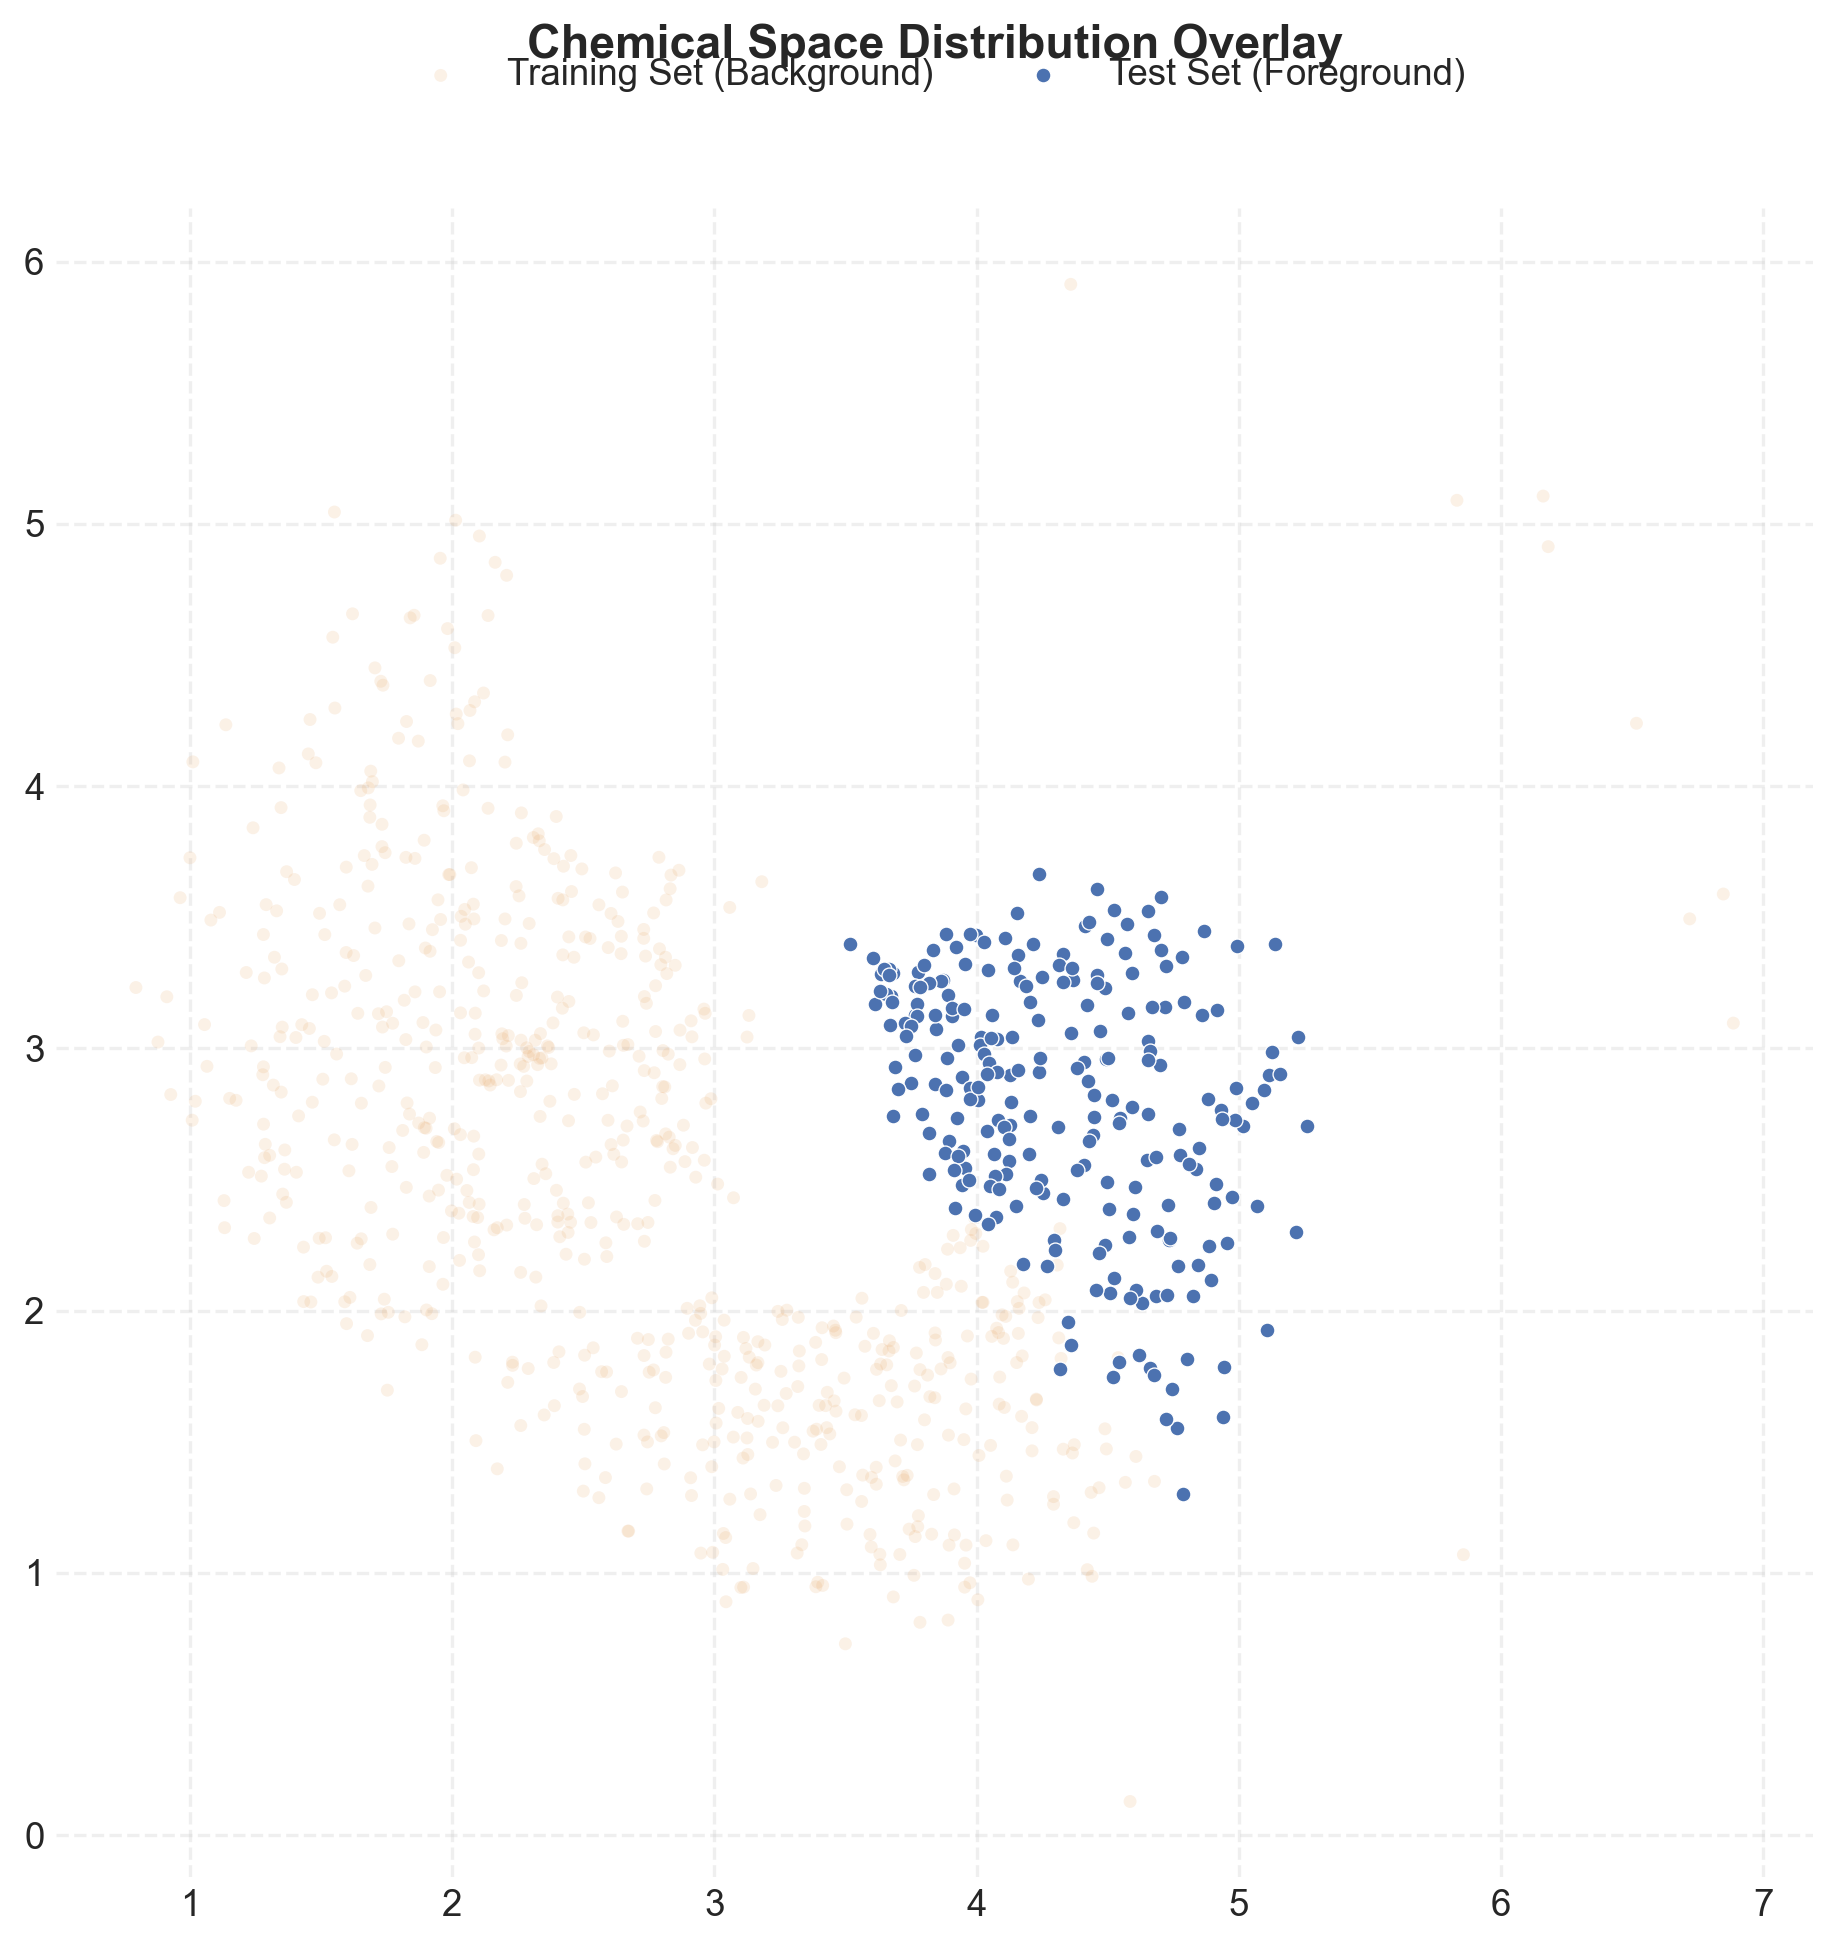

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 模拟环境配置 (请确保 CONFIG 已定义)
# ==========================================
# 假设您的 processed_csvs 列表里包含两个文件：一个训练集，一个测试集

def plot_refined_umap(processed_csvs, featurizer):
    all_features = []
    dataset_labels = []
    dataset_sizes = []

    # 数据加载（取消合并操作）
    for csv_file in processed_csvs:
        # 假设 extract_rdkit_features 返回包含 {"X": numpy_array} 的字典
        stats = extract_rdkit_features(csv_file, CONFIG['features_dir'], featurizer)
        
        if "error" not in stats:
            current_X = stats["X"]
            
            # --- 取消合并操作，使用原始数据 ---
            all_features.append(current_X)
            # 记录文件名，用于后续判断哪个是 Train 哪个是 Test
            dataset_labels.append(csv_file.name)
            dataset_sizes.append(len(current_X))
            print(f"✓ {csv_file.name}: 原始数据点数量 {len(current_X)}")

    if not all_features:
        print("错误：未收集到有效数据。")
        return

    # 合并数据并标准化
    X_combined = np.vstack(all_features)
    X_scaled = StandardScaler().fit_transform(X_combined)

    # 执行 UMAP 降维
    print("\n正在执行 UMAP 降维 (Jaccard Metric)...")
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.3,
        metric='jaccard', # 针对分子指纹建议使用 jaccard
        random_state=42
    )
    embedding = reducer.fit_transform(X_scaled)

    # ==========================================
    # 3. 高级可视化绘图 (分层逻辑)
    # ==========================================
    sns.set_context("notebook")
    plt.style.use('seaborn-v0_8-white')
    
    # 强制正方形画布
    fig, ax = plt.subplots(figsize=(8, 8), dpi=120)

    # 定义颜色和层级逻辑
    # 我们需要根据文件名识别 Train 和 Test
    start = 0
    # 为了保证 Test 在最上面，我们先循环找 Train 绘制底层，再找 Test 绘制顶层
    
    # 第一遍遍历：绘制训练集 (作为半透明背景)
    for i, (name, size) in enumerate(zip(dataset_labels, dataset_sizes)):
        end = start + size
        if "train" in name.lower():
            ax.scatter(
                embedding[start:end, 0], 
                embedding[start:end, 1], 
                label="Training Set (Background)",
                alpha=0.15,          # 极低透明度，让它变成淡黄色的云
                s=15,                # 点更小，减少视觉拥挤
                color='#E6A15C',     # 高级感橙黄色
                edgecolors='none',
                zorder=1             # 底层渲染
            )
        start = end

    # 第二遍遍历：绘制测试集 (作为清晰前景)
    start = 0
    for i, (name, size) in enumerate(zip(dataset_labels, dataset_sizes)):
        end = start + size
        if "test" in name.lower():
            ax.scatter(
                embedding[start:end, 0], 
                embedding[start:end, 1], 
                label="Test Set (Foreground)",
                alpha=1.0,           # 完全不透明
                s=20,                # 点更小，保持比例
                color='#4C72B0',     # 莫兰迪蓝色
                edgecolors='white',  # 增加白边增加立体感
                linewidths=0.4,      # 边线更细
                zorder=10            # 强制顶层渲染，不被黄色掩盖
            )
        start = end

    # 保留被注释的片段（取消注释）
    '''
    start = 0
    for i, (name, size) in enumerate(zip(dataset_labels, dataset_sizes)):
        end = start + size
        if "mix" in name.lower():
            ax.scatter(
                embedding[start:end, 0], 
                embedding[start:end, 1], 
                label="mixture Set (Foreground)",
                alpha=1.0,           # 完全不透明   
                s=20,                # 点更小，保持比例
                color='#AA0000',     # 红色
                edgecolors='white',  # 增加白边增加立体感
                linewidths=0.4,      # 边线更细
                zorder=10            # 强制顶层渲染，不被黄色掩盖
            )
        start = end
    '''

    # --- 样式调整 ---
    
    # 1. 强制 1:1 坐标比例 (呈现真正的正方形空间分布)
    ax.set_aspect('equal', adjustable='box')
    
    # 2. 隐藏冗余刻度线，增加网格感
    ax.grid(True, linestyle='--', alpha=0.3)
    sns.despine(left=True, bottom=True)

    # 3. 图例置于图片正上方
    ax.legend(
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.05), 
        ncol=2, 
        frameon=False,
        fontsize=11
    )

    # 4. 标题与布局
    ax.set_title("Chemical Space Distribution Overlay", pad=45, fontweight='bold', fontsize=14)
    plt.tight_layout()
    
    plt.show()

# 执行函数
plot_refined_umap(processed_csvs, featurizer)